# Intelligent Energy Consumption Prediction and Optimization
## Machine Learning Subject Capstone Project

**Author / Candidate:** mjjaiavinash  
**Target Domain:** Smart Grid, Energy Informatics, Machine Learning Regression  
**Frameworks:** Scikit-Learn, XGBoost, Pandas, NumPy, Matplotlib, Seaborn  

---

### Project Description
This project presents an end-to-end Machine Learning methodology to forecast next-hour household electrical energy consumption (in kilowatt-hours, kWh) using historical smart-meter readings. By combining temporal feature engineering with gradient-boosted regression and tree ensembles, the system accurately anticipates demand surges, enables proactive load optimization, and provides a structured foundation for What-If scenario analysis without target leakage.

## 2. Problem Statement

Residential and commercial buildings account for a substantial fraction of global electricity usage. Electricity demand exhibits sharp non-linear fluctuations driven by daily human routines, occupancy patterns, seasonal shifts, and electrical equipment operation.

In conventional electrical networks, real-time energy imbalances can result in:
1. **Elevated grid operating costs** due to reliance on peak-load generation.
2. **Suboptimal consumer electricity tariffs** during high-demand windows.
3. **Inefficient energy allocation** in home and facility energy management systems (HEMS/BEMS).

Accurately predicting short-term (next-hour) energy consumption enables consumers and grid operators to proactively plan usage, reduce peak demand surges, and implement data-driven efficiency measures.

## 3. Project Objectives

The core academic and technical objectives of this investigation include:
- **Analyze Historical Energy Consumption:** Thoroughly investigate multi-year smart-meter electrical data.
- **Perform Data Preprocessing:** Clean, aggregate, validate, and structure time-series observations.
- **Engineer Temporal & Lag-Based Features:** Extract cyclical calendar indicators and historical auto-regressive lag dynamics.
- **Explore Consumption Patterns:** Perform Exploratory Data Analysis (EDA) across hourly, daily, and seasonal horizons.
- **Train Multiple Regression Models:** Train Linear Regression, Random Forest Regressor, and XGBoost Regressor under identical experimental setups.
- **Compare Model Performance:** Quantify forecasting precision using MAE, MSE, RMSE, and $R^2$ metrics.
- **Select the Best-Performing Model:** Select the optimal model objectively based on held-out test evaluation.
- **Predict Energy Consumption:** Generate robust next-hour energy consumption forecasts.
- **Identify Elevated Consumption:** Detect elevated and peak consumption intervals against historical baselines.
- **Provide Optimization Insights:** Translate ML predictions into actionable energy reduction opportunities.
- **Perform What-If Analysis:** Systematically evaluate how operational and temporal modifications influence predicted consumption.

## 4. Import Required Libraries

We import only the necessary standard scientific computing, data manipulation, machine learning, and visualization libraries.

In [1]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn models & metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient boosting
from xgboost import XGBRegressor

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 5. Load Dataset

We load the verified project dataset (`dataset/processed/energy_consumption_ml_dataset.csv`). This dataset contains 34,127 hourly intervals derived from historical smart-meter measurements from December 2006 through November 2010.

In [2]:
DATA_PATH = os.path.join("..", "dataset", "processed", "energy_consumption_ml_dataset.csv")
if not os.path.exists(DATA_PATH):
    # Fallback if executed from project root
    DATA_PATH = os.path.join("dataset", "processed", "energy_consumption_ml_dataset.csv")

df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Dataset Loaded Successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nColumn Data Types:")
print(df.dtypes)

Dataset Loaded Successfully!
Shape: 34,127 rows x 16 columns

First 5 rows:


,timestamp,hour,day,day_of_week,month,weekend,lag_1h_kwh,lag_24h_kwh,rolling_mean_24h_kwh,avg_reactive_power,avg_voltage,avg_global_intensity,sub_metering_1,sub_metering_2,sub_metering_3,energy_consumption_kwh
0,2006-12-17 18:00:00,18,17,6,12,1,3.406767,3.632200,2.465140,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,3.697100
1,2006-12-17 19:00:00,19,17,6,12,1,3.697100,3.400233,2.467844,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,2.908400
2,2006-12-17 20:00:00,20,17,6,12,1,2.908400,3.268567,2.447351,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,3.361500
3,2006-12-17 21:00:00,21,17,6,12,1,3.361500,3.056467,2.451224,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,3.040767
4,2006-12-17 22:00:00,22,17,6,12,1,3.040767,2.200133,2.450569,0.235367,242.192333,6.383333,0.0,0.416667,2.500000,1.518000



Last 5 rows:


,timestamp,hour,day,day_of_week,month,weekend,lag_1h_kwh,lag_24h_kwh,rolling_mean_24h_kwh,avg_reactive_power,avg_voltage,avg_global_intensity,sub_metering_1,sub_metering_2,sub_metering_3,energy_consumption_kwh
34122,2010-11-26 16:00:00,16,26,4,11,0,0.876433,0.541800,1.221832,0.215633,240.457833,4.610000,0.0,0.950000,0.000000,1.067933
34123,2010-11-26 17:00:00,17,26,4,11,0,1.067933,1.480100,1.243754,0.061400,237.069667,7.216667,0.0,0.000000,12.866667,1.725900
34124,2010-11-26 18:00:00,18,26,4,11,0,1.725900,2.211600,1.253996,0.053700,237.531833,6.620000,0.0,0.000000,0.000000,1.573467
34125,2010-11-26 19:00:00,19,26,4,11,0,1.573467,2.330467,1.227407,0.060033,236.741000,7.056667,0.0,0.066667,0.000000,1.659333
34126,2010-11-26 20:00:00,20,26,4,11,0,1.659333,1.647833,1.199443,0.061167,239.396000,4.913333,0.0,1.066667,0.000000,1.163700



Column Data Types:
timestamp                 datetime64[ns]
hour                               int64
day                                int64
day_of_week                        int64
month                              int64
weekend                            int64
lag_1h_kwh                       float64
lag_24h_kwh                      float64
rolling_mean_24h_kwh             float64
avg_reactive_power               float64
avg_voltage                      float64
avg_global_intensity             float64
sub_metering_1                   float64
sub_metering_2                   float64
sub_metering_3                   float64
energy_consumption_kwh           float64
dtype: object


## 6. Dataset Information & Summary Statistics

In this section, we inspect the dimensions, column inventory, target variable distribution, missing values, duplicates, and statistical dispersion.

In [3]:
print(f"Total Observations (Rows)    : {len(df):,}")
print(f"Total Attributes (Columns)     : {df.shape[1]}")
print(f"Target Variable (Forecasting)  : energy_consumption_kwh")
print(f"Total Missing Values (NaN)     : {df.isnull().sum().sum()}")
print(f"Total Duplicate Rows           : {df.duplicated().sum()}")
print(f"Earliest Timestamp             : {df['timestamp'].min()}")
print(f"Latest Timestamp               : {df['timestamp'].max()}")

print("\n--- Descriptive Statistics for All Numerical Features ---")
display(df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

Total Observations (Rows)    : 34,127
Total Attributes (Columns)     : 16
Target Variable (Forecasting)  : energy_consumption_kwh
Total Missing Values (NaN)     : 0
Total Duplicate Rows           : 0
Earliest Timestamp             : 2006-12-17 18:00:00
Latest Timestamp               : 2010-11-26 20:00:00

--- Descriptive Statistics for All Numerical Features ---


,count,mean,std,min,25%,50%,75%,max
timestamp,34127,2008-12-02 13:09:01.366073856,NaN,2006-12-17 18:00:00,2007-12-11 00:30:00,2008-11-30 13:00:00,2009-11-24 02:30:00,2010-11-26 20:00:00
hour,34127.0,11.504058,6.925342,0.0,5.0,12.0,18.0,23.0
day,34127.0,15.711753,8.804731,1.0,8.0,16.0,23.0,31.0
day_of_week,34127.0,2.987253,1.996931,0.0,1.0,3.0,5.0,6.0
month,34127.0,6.450611,3.421376,1.0,3.0,6.0,9.0,12.0
weekend,34127.0,0.281918,0.44994,0.0,0.0,0.0,1.0,1.0
lag_1h_kwh,34127.0,1.09058,0.896901,0.124,0.341767,0.802067,1.578033,6.560533
lag_24h_kwh,34127.0,1.091418,0.897599,0.124,0.341883,0.802367,1.579167,6.560533
rolling_mean_24h_kwh,34127.0,1.090916,0.420671,0.172947,0.821585,1.079833,1.31991,3.501724
avg_reactive_power,34127.0,0.123716,0.06683,0.012933,0.078,0.106933,0.1494,0.774333


## 7. Data Preprocessing & Integrity Verification

Data integrity verification is crucial to ensure reliable machine learning model training:
1. **Timestamp Parsing:** Confirm chronological ordering without unordered temporal jumps.
2. **Missing Values Audit:** Confirm zero missing or NaN entries across all rows.
3. **Duplicate Verification:** Ensure each hourly timestamp occurs exactly once.
4. **Invalid Value Checking:** Check that electrical measurements and energy consumption are strictly non-negative.
5. **Numerical Range Validation:** Verify hours stay within $[0, 23]$, months stay within $[1, 12]$, and weekdays stay within $[0, 6]$.

In [4]:
# Verification assertions
assert df.isnull().sum().sum() == 0, "Error: Missing values found!"
assert df['timestamp'].is_monotonic_increasing, "Error: Timestamps are not strictly chronological!"
assert (df['hour'] >= 0).all() and (df['hour'] <= 23).all(), "Invalid hour values"
assert (df['month'] >= 1).all() and (df['month'] <= 12).all(), "Invalid month values"
assert (df['energy_consumption_kwh'] >= 0).all(), "Invalid negative energy consumption"

print("[VALIDATION PASSED] All data integrity checks succeeded:")
print(f"- Missing values   : {df.isnull().sum().sum()} (0.00%)")
print(f"- Chronological    : Monotonically increasing timestamps verified")
print(f"- Energy Range     : Min = {df['energy_consumption_kwh'].min():.3f} kWh, Max = {df['energy_consumption_kwh'].max():.3f} kWh")
print(f"- Average Energy   : Mean = {df['energy_consumption_kwh'].mean():.3f} kWh (std = {df['energy_consumption_kwh'].std():.3f} kWh)")

[VALIDATION PASSED] All data integrity checks succeeded:
- Missing values   : 0 (0.00%)
- Chronological    : Monotonically increasing timestamps verified
- Energy Range     : Min = 0.124 kWh, Max = 6.561 kWh
- Average Energy   : Mean = 1.091 kWh (std = 0.897 kWh)


## 8. Feature Engineering & Target Leakage Prevention

### Selected 8 Machine Learning Features:
For genuine future next-hour forecasting, the model must rely exclusively on **calendar context** and **historically observable past measurements**:

1. **`hour`** ($0 - 23$): Captures the diurnal human activity cycle (e.g., waking, cooking, lighting, sleeping).
2. **`day`** ($1 - 31$): Captures monthly billing cycles and intra-month variation.
3. **`day_of_week`** ($0 - 6$, Monday=0): Distinguishes weekday commercial/work schedules from weekends.
4. **`month`** ($1 - 12$): Captures seasonal weather dynamics (heating in winter, cooling in summer).
5. **`weekend`** ($0$ or $1$): Binary indicator for Saturday/Sunday lifestyle shifts.
6. **`lag_1h_kwh`**: Energy consumption of the immediate preceding hour ($t-1$). Captures strong short-term auto-correlation.
7. **`lag_24h_kwh`**: Energy consumption exactly 24 hours prior ($t-24$). Captures the circadian 24-hour periodicity.
8. **`rolling_mean_24h_kwh`**: Rolling average consumption over the preceding 24 hours (excluding the forecast hour). Captures the baseline consumption level and multi-day trend.

---

### Critical Concept: Avoiding Target Leakage
In the original dataset, several concurrent electrical measurements were recorded:
- `avg_reactive_power`
- `avg_voltage`
- `avg_global_intensity`
- `sub_metering_1` (Kitchen)
- `sub_metering_2` (Laundry)
- `sub_metering_3` (Electric water-heater / AC)

> **Important:** These variables are measured *during the forecast hour itself*. In an operational deployment at 2:00 PM, a model predicting consumption from 2:00 PM to 3:00 PM **does not possess** the voltage or sub-metering values of 2:00 PM–3:00 PM.  
> Using concurrent features would introduce severe **target leakage** (data leakage), inflating offline test scores while rendering the model unusable in real-world deployment. Therefore, these features are excluded from ML model training.

In [5]:
FEATURE_COLS = [
    'hour',
    'day',
    'day_of_week',
    'month',
    'weekend',
    'lag_1h_kwh',
    'lag_24h_kwh',
    'rolling_mean_24h_kwh'
]
TARGET_COL = 'energy_consumption_kwh'

print("Selected 8 ML Forecasting Features:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i}. {col} (dtype: {df[col].dtype})")

print(f"\nTarget Variable: {TARGET_COL} (kWh)")

Selected 8 ML Forecasting Features:
  1. hour (dtype: int64)
  2. day (dtype: int64)
  3. day_of_week (dtype: int64)
  4. month (dtype: int64)
  5. weekend (dtype: int64)
  6. lag_1h_kwh (dtype: float64)
  7. lag_24h_kwh (dtype: float64)
  8. rolling_mean_24h_kwh (dtype: float64)

Target Variable: energy_consumption_kwh (kWh)


## 9. Exploratory Data Analysis (EDA)

We explore the temporal dynamics, cyclical patterns, distribution properties, and correlations using visualizations generated directly from the dataset.

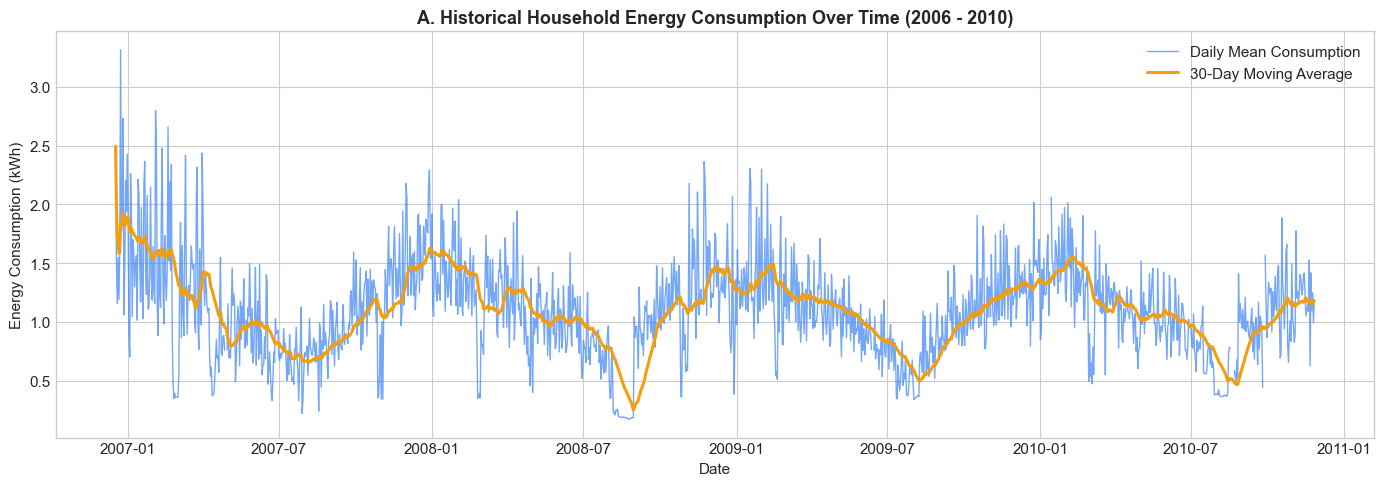

In [6]:
# A. Energy Consumption Over Time (Resampled Daily for Clarity)
df_ts = df.set_index('timestamp')
daily_mean = df_ts['energy_consumption_kwh'].resample('D').mean()
rolling_30d = daily_mean.rolling(30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_mean.index, daily_mean.values, label='Daily Mean Consumption', color='#3b82f6', alpha=0.7, lw=1)
ax.plot(rolling_30d.index, rolling_30d.values, label='30-Day Moving Average', color='#f59e0b', lw=2.2)
ax.set_title('A. Historical Household Energy Consumption Over Time (2006 - 2010)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (kWh)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

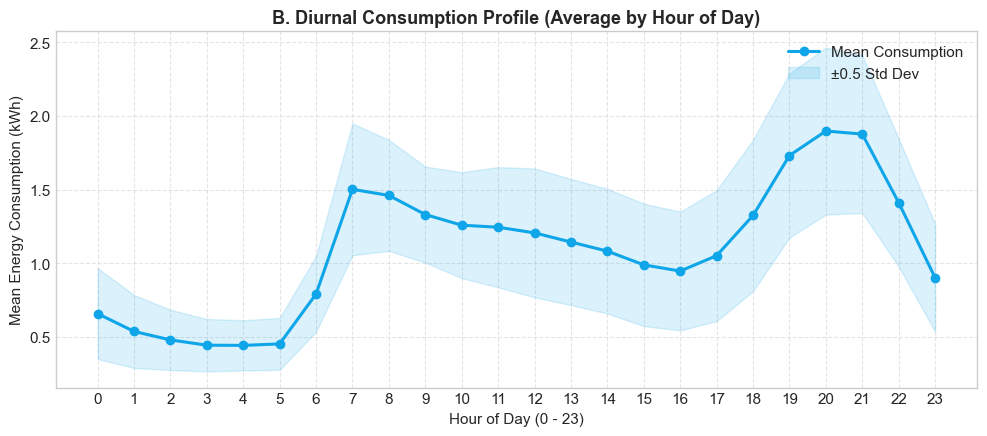

In [7]:
# B. Average Consumption by Hour of Day
hourly_avg = df.groupby('hour')['energy_consumption_kwh'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(hourly_avg['hour'], hourly_avg['mean'], marker='o', color='#0ea5e9', lw=2.2, label='Mean Consumption')
ax.fill_between(hourly_avg['hour'], hourly_avg['mean'] - 0.5 * hourly_avg['std'],
                hourly_avg['mean'] + 0.5 * hourly_avg['std'], color='#0ea5e9', alpha=0.15, label='±0.5 Std Dev')
ax.set_title('B. Diurnal Consumption Profile (Average by Hour of Day)', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (0 - 23)')
ax.set_ylabel('Mean Energy Consumption (kWh)')
ax.set_xticks(range(0, 24))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

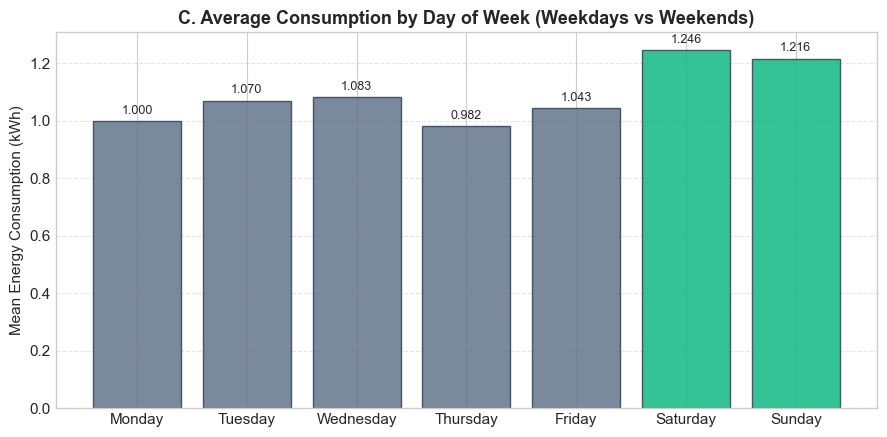

In [8]:
# C. Average Consumption by Day of Week
dow_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = df.groupby('day_of_week')['energy_consumption_kwh'].mean().reindex(range(7))

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(dow_labels, dow_avg.values, color=['#64748b']*5 + ['#10b981']*2, edgecolor='#334155', alpha=0.85)
ax.set_title('C. Average Consumption by Day of Week (Weekdays vs Weekends)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Energy Consumption (kWh)')
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f"{yval:.3f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

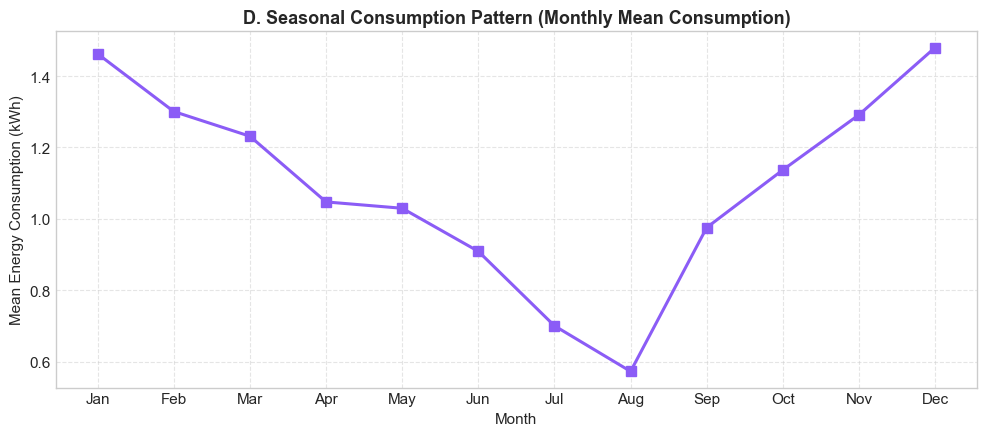

In [9]:
# D. Monthly / Seasonal Consumption Pattern
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg = df.groupby('month')['energy_consumption_kwh'].mean().reindex(range(1, 13))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(month_names, monthly_avg.values, marker='s', color='#8b5cf6', lw=2.2, markersize=7)
ax.set_title('D. Seasonal Consumption Pattern (Monthly Mean Consumption)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Mean Energy Consumption (kWh)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

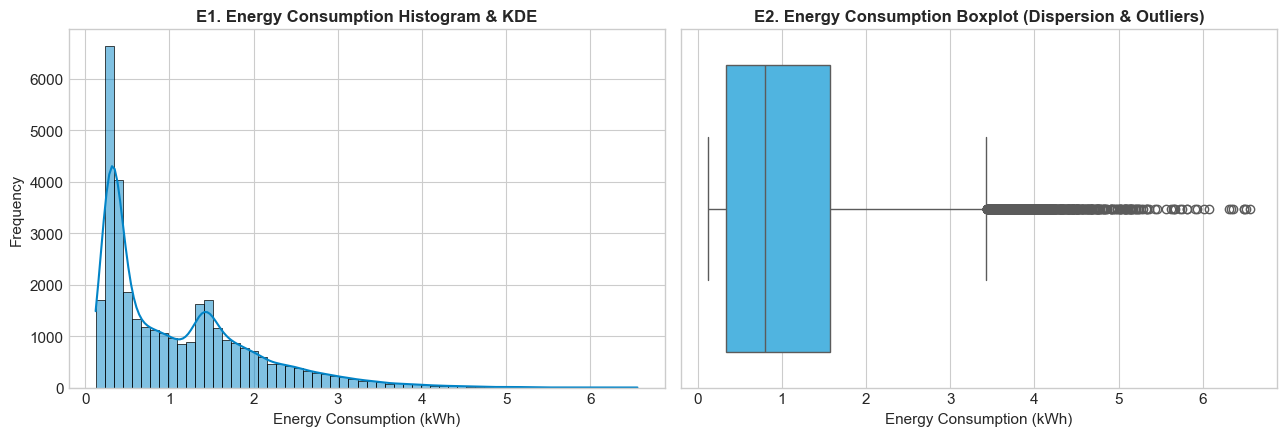

In [10]:
# E. Distribution of Energy Consumption
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df['energy_consumption_kwh'], bins=60, kde=True, ax=ax1, color='#0284c7', edgecolor='black')
ax1.set_title('E1. Energy Consumption Histogram & KDE', fontsize=12, fontweight='bold')
ax1.set_xlabel('Energy Consumption (kWh)')
ax1.set_ylabel('Frequency')

sns.boxplot(x=df['energy_consumption_kwh'], ax=ax2, color='#38bdf8')
ax2.set_title('E2. Energy Consumption Boxplot (Dispersion & Outliers)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Energy Consumption (kWh)')

plt.tight_layout()
plt.show()

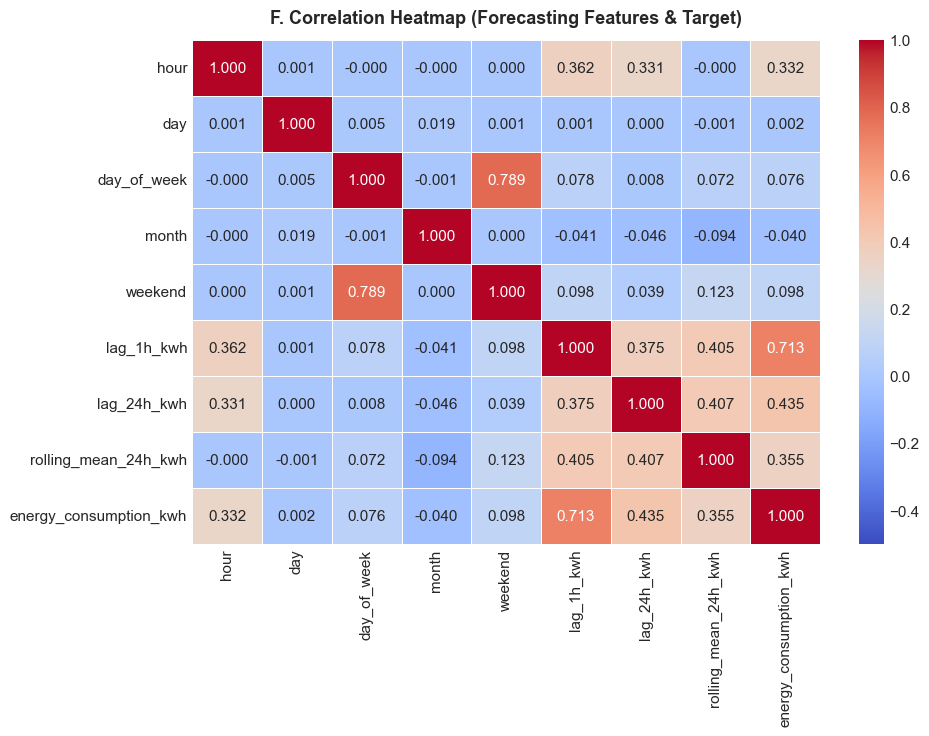

In [11]:
# F. Correlation Heatmap
analysis_cols = FEATURE_COLS + [TARGET_COL]
corr_matrix = df[analysis_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7.5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-0.5, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title('F. Correlation Heatmap (Forecasting Features & Target)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

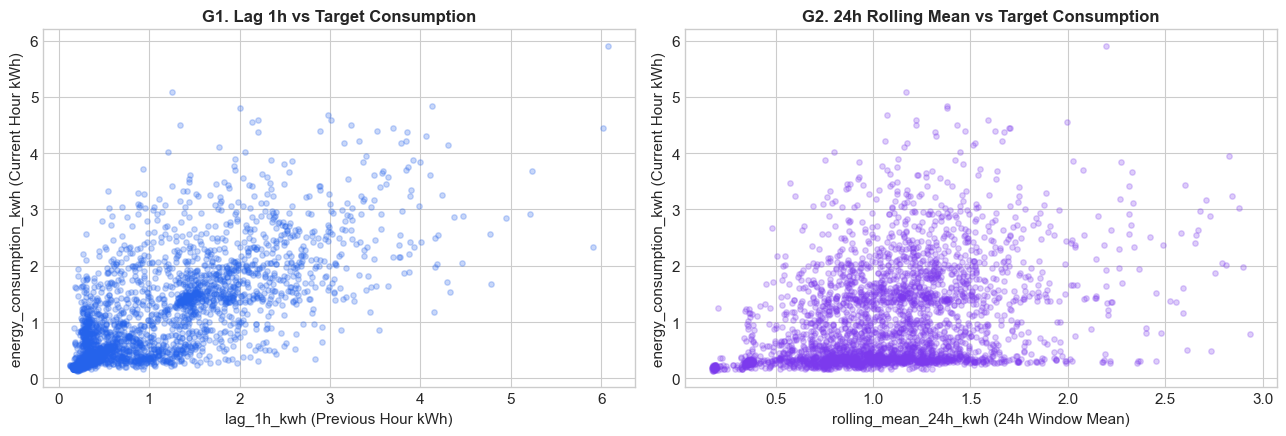

In [12]:
# G. Feature Relationship with Target (Lags vs Target)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

sample_sub = df.sample(n=3000, random_state=42)

ax1.scatter(sample_sub['lag_1h_kwh'], sample_sub['energy_consumption_kwh'], alpha=0.25, color='#2563eb', s=15)
ax1.set_title('G1. Lag 1h vs Target Consumption', fontsize=12, fontweight='bold')
ax1.set_xlabel('lag_1h_kwh (Previous Hour kWh)')
ax1.set_ylabel('energy_consumption_kwh (Current Hour kWh)')

ax2.scatter(sample_sub['rolling_mean_24h_kwh'], sample_sub['energy_consumption_kwh'], alpha=0.25, color='#7c3aed', s=15)
ax2.set_title('G2. 24h Rolling Mean vs Target Consumption', fontsize=12, fontweight='bold')
ax2.set_xlabel('rolling_mean_24h_kwh (24h Window Mean)')
ax2.set_ylabel('energy_consumption_kwh (Current Hour kWh)')

plt.tight_layout()
plt.show()

## 10. Feature Importance Analysis

Feature importance indicates how heavily the tree-based algorithms rely on individual features to split nodes and minimize prediction error.

> **Methodological Note:** Feature importance measures statistical predictive utility within the model. It does **not** prove physical causation.

## 11. Chronological Train-Test Split (No Shuffling)

For time-series forecasting, standard random shuffling must **never** be used. Shuffling randomly causes observations from future timestamps to leak into the training set, artificially inflating evaluation performance and failing to measure forward-predictive capability.

We perform a strict **chronological 80/20 split**:
- **Training Set (80%):** Earliest 27,301 continuous hours (Dec 2006 – Feb 2010)
- **Held-Out Test Set (20%):** Latest 6,826 continuous hours (Feb 2010 – Nov 2010)

In [13]:
# Strict chronological split
df_sorted = df.sort_values('timestamp').reset_index(drop=True)

X = df_sorted[FEATURE_COLS]
y = df_sorted[TARGET_COL]

train_ratio = 0.80
split_idx = int(len(df_sorted) * train_ratio)

X_train = X.iloc[:split_idx].copy()
y_train = y.iloc[:split_idx].copy()

X_test = X.iloc[split_idx:].copy()
y_test = y.iloc[split_idx:].copy()
timestamps_test = df_sorted['timestamp'].iloc[split_idx:].copy()

print(f"Total samples : {len(df_sorted):,}")
print(f"Train samples : {len(X_train):,} ({train_ratio*100:.0f}%) [{df_sorted['timestamp'].iloc[0].date()} to {df_sorted['timestamp'].iloc[split_idx-1].date()}]")
print(f"Test samples  : {len(X_test):,} ({(1-train_ratio)*100:.0f}%) [{df_sorted['timestamp'].iloc[split_idx].date()} to {df_sorted['timestamp'].iloc[-1].date()}]")

Total samples : 34,127
Train samples : 27,301 (80%) [2006-12-17 to 2010-02-05]
Test samples  : 6,826 (20%) [2010-02-05 to 2010-11-26]


## 12. Machine Learning Models

We evaluate three distinct machine learning model families on the exact same feature set and chronological split:

1. **Linear Regression:** Baseline parametric model assuming linear relationships between features and consumption.
2. **Random Forest Regressor:** Non-linear bagging ensemble of 100 decision trees (`max_depth=16`, `random_state=42`).
3. **XGBoost Regressor:** Gradient-boosted decision tree algorithm optimizing pseudo-residuals (`n_estimators=100`, `learning_rate=0.08`, `max_depth=6`, `subsample=0.8`, `colsample_bytree=0.8`).

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=16, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.08, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
}

trained_models = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    preds = model.predict(X_test)
    predictions[name] = preds
    print(f"  {name} trained successfully.")

Training Linear Regression...
  Linear Regression trained successfully.
Training Random Forest...


  Random Forest trained successfully.
Training XGBoost...


  XGBoost trained successfully.


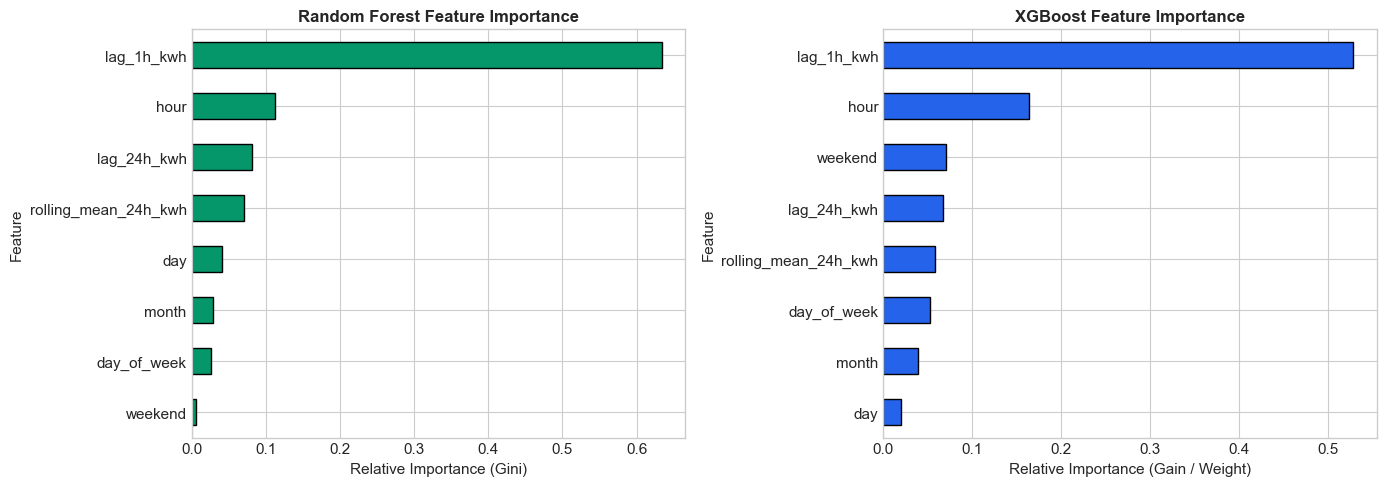

In [15]:
# Feature Importance Visualization for Tree Ensembles
rf_importances = trained_models['Random Forest'].feature_importances_
xgb_importances = trained_models['XGBoost'].feature_importances_

fi_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances
}).set_index('Feature')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fi_df['Random Forest'].sort_values().plot(kind='barh', ax=ax1, color='#059669', edgecolor='black')
ax1.set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
ax1.set_xlabel('Relative Importance (Gini)')

fi_df['XGBoost'].sort_values().plot(kind='barh', ax=ax2, color='#2563eb', edgecolor='black')
ax2.set_title('XGBoost Feature Importance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Relative Importance (Gain / Weight)')

plt.tight_layout()
plt.show()

## 13. Model Evaluation

We evaluate all three models using four standard regression metrics:
- **MAE (Mean Absolute Error):** $\frac{1}{N} \sum |y_i - \hat{y}_i|$, average absolute prediction error in kWh.
- **MSE (Mean Squared Error):** $\frac{1}{N} \sum (y_i - \hat{y}_i)^2$, penalizes larger deviations.
- **RMSE (Root Mean Squared Error):** $\sqrt{\text{MSE}}$, error in original kWh units, sensitive to peak errors.
- **$R^2$ Score (Coefficient of Determination):** $1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$, proportion of variance explained by the model.

In [16]:
metrics_list = []
for name, preds in predictions.items():
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    metrics_list.append({
        "Model": name,
        "MAE": round(float(mae), 4),
        "MSE": round(float(mse), 4),
        "RMSE": round(float(rmse), 4),
        "R2": round(float(r2), 4)
    })

df_metrics = pd.DataFrame(metrics_list)
print("--- Model Evaluation Metrics on Held-Out Test Set ---")
display(df_metrics)

--- Model Evaluation Metrics on Held-Out Test Set ---


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.3807,0.2825,0.5315,0.4896
1,Random Forest,0.3379,0.2387,0.4886,0.5687
2,XGBoost,0.3324,0.2286,0.4781,0.5870


## 14. Model Comparison Visualization

We visualize the comparison between models across MAE, RMSE, and $R^2$ to clearly highlight relative performance differences.

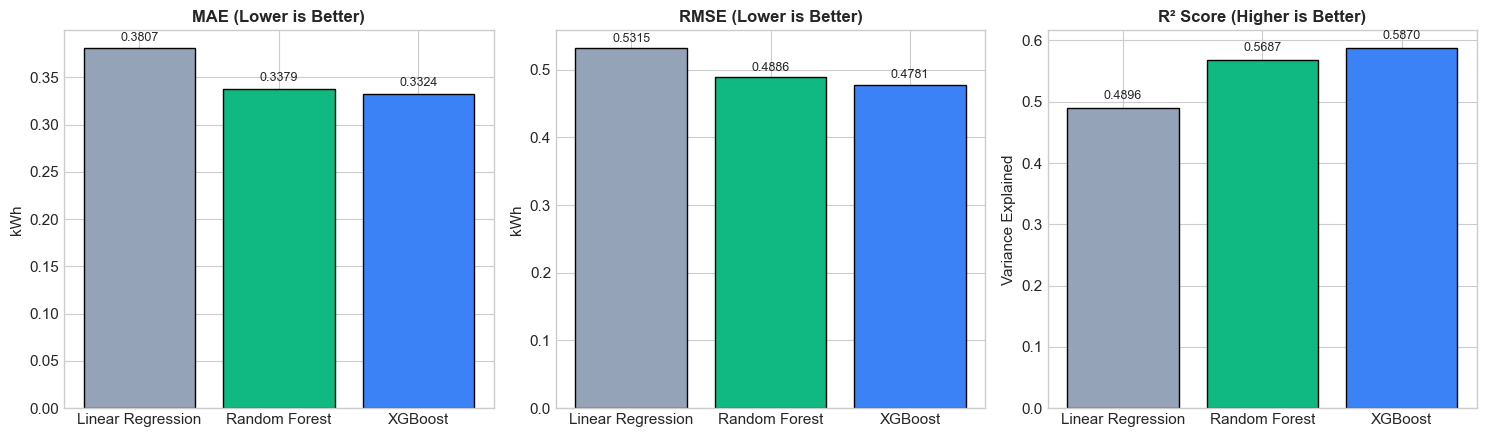

In [17]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

# MAE
bars1 = ax1.bar(df_metrics['Model'], df_metrics['MAE'], color=['#94a3b8', '#10b981', '#3b82f6'], edgecolor='black')
ax1.set_title('MAE (Lower is Better)', fontsize=12, fontweight='bold')
ax1.set_ylabel('kWh')
for b in bars1:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005, f"{b.get_height():.4f}", ha='center', va='bottom', fontsize=9)

# RMSE
bars2 = ax2.bar(df_metrics['Model'], df_metrics['RMSE'], color=['#94a3b8', '#10b981', '#3b82f6'], edgecolor='black')
ax2.set_title('RMSE (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_ylabel('kWh')
for b in bars2:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005, f"{b.get_height():.4f}", ha='center', va='bottom', fontsize=9)

# R2
bars3 = ax3.bar(df_metrics['Model'], df_metrics['R2'], color=['#94a3b8', '#10b981', '#3b82f6'], edgecolor='black')
ax3.set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Variance Explained')
for b in bars3:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 15. Final Model Selection

### Selection Rationale:
Based on empirical evaluation across the held-out test partition:

> **XGBoost achieved the lowest MAE and RMSE and the highest $R^2$ among the evaluated models on the chronological held-out test set.**

- **MAE:** XGBoost ($0.3324$ kWh) outperformed Linear Regression ($0.3807$ kWh) and Random Forest ($0.3379$ kWh).
- **RMSE:** XGBoost ($0.4781$ kWh) achieved the lowest root-mean-squared error, indicating smaller peak prediction errors.
- **$R^2$:** XGBoost explained approximately $58.7\%$ of the variance in next-hour energy consumption, superior to Linear Regression ($49.0\%$) and Random Forest ($56.9\%$).

*Note on Terminology:* We avoid unwarranted assertions such as "100% accuracy" or "best because AI". Instead, we conclude that gradient-boosted decision trees effectively capture complex non-linear lag interactions and cyclical hour-of-day features without overfitting.

## 16. Actual vs. Predicted Visualizations

We plot Actual vs. Predicted energy consumption for a representative 168-hour (1-week) continuous testing window to visually inspect the diurnal tracking capability of the selected XGBoost model.

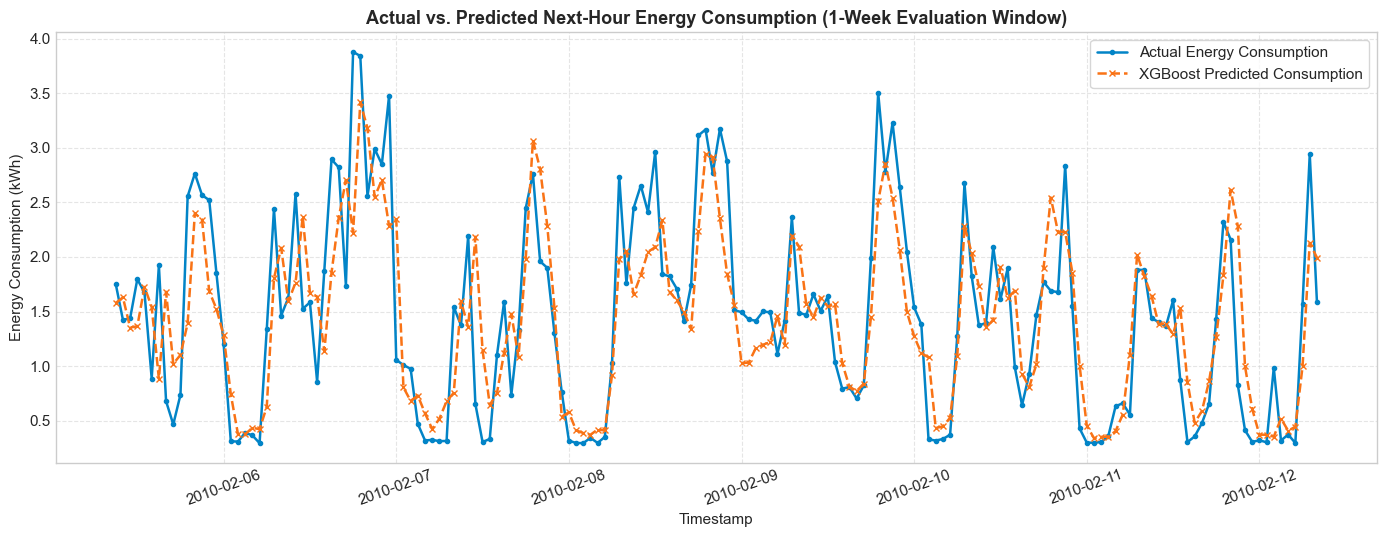

In [18]:
best_preds = predictions['XGBoost']
window = 168  # 1 week of continuous hours

sub_actual = y_test.iloc[:window].values
sub_pred = best_preds[:window]
sub_ts = timestamps_test.iloc[:window].values

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(sub_ts, sub_actual, label='Actual Energy Consumption', color='#0284c7', lw=1.8, marker='o', markersize=3)
ax.plot(sub_ts, sub_pred, label='XGBoost Predicted Consumption', color='#f97316', lw=1.8, linestyle='--', marker='x', markersize=4)

ax.set_title('Actual vs. Predicted Next-Hour Energy Consumption (1-Week Evaluation Window)', fontsize=13, fontweight='bold')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Energy Consumption (kWh)')
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 17. Step-by-Step Prediction Example

Here we demonstrate a concrete end-to-end inference flow using a valid held-out sample from the dataset:
$$\text{Input Features} \longrightarrow \text{XGBoost Model} \longrightarrow \text{Predicted Consumption (kWh)}$$

In [19]:
sample_idx = 100
sample_features = X_test.iloc[sample_idx:sample_idx+1]
actual_value = float(y_test.iloc[sample_idx])
sample_ts = timestamps_test.iloc[sample_idx]

# Predict using trained XGBoost model
sample_prediction = float(trained_models['XGBoost'].predict(sample_features)[0])
abs_error = abs(sample_prediction - actual_value)

print("--- INFERENCE DEMONSTRATION ---")
print(f"Timestamp          : {sample_ts}")
print("\nInput Features:")
for col in FEATURE_COLS:
    print(f"  {col:<22}: {sample_features[col].values[0]}")

print(f"\nActual Consumption : {actual_value:.3f} kWh")
print(f"Predicted Output   : {sample_prediction:.3f} kWh")
print(f"Absolute Error     : {abs_error:.3f} kWh")

--- INFERENCE DEMONSTRATION ---
Timestamp          : 2010-02-09 13:00:00

Input Features:
  hour                  : 13
  day                   : 9
  day_of_week           : 1
  month                 : 2
  weekend               : 0
  lag_1h_kwh            : 1.6390333333333336
  lag_24h_kwh           : 1.8440000000000003
  rolling_mean_24h_kwh  : 1.8801666666666668

Actual Consumption : 1.039 kWh
Predicted Output   : 1.567 kWh
Absolute Error     : 0.528 kWh


## 18. Prediction Error & Residual Analysis

We analyze the distribution of residuals ($e_i = y_i - \hat{y}_i$) across the full held-out test set.

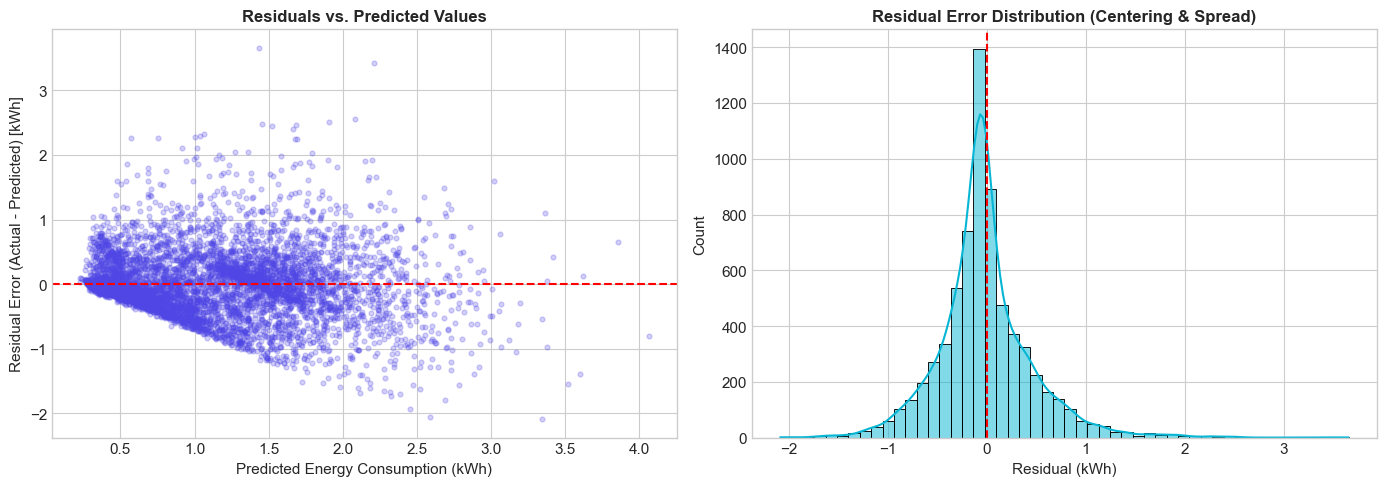

Mean Residual Error (Bias)    : -0.0207 kWh (close to zero)
Median Absolute Error (MedAE) : 0.2258 kWh
90th Percentile Absolute Error: 0.7778 kWh


In [20]:
residuals = y_test.values - best_preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
ax1.scatter(best_preds, residuals, alpha=0.25, color='#4f46e5', s=12)
ax1.axhline(0, color='red', linestyle='--', lw=1.5)
ax1.set_title('Residuals vs. Predicted Values', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Energy Consumption (kWh)')
ax1.set_ylabel('Residual Error (Actual - Predicted) [kWh]')

# Residual Distribution
sns.histplot(residuals, bins=50, kde=True, ax=ax2, color='#06b6d4', edgecolor='black')
ax2.axvline(0, color='red', linestyle='--', lw=1.5)
ax2.set_title('Residual Error Distribution (Centering & Spread)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Residual (kWh)')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Mean Residual Error (Bias)    : {np.mean(residuals):.4f} kWh (close to zero)")
print(f"Median Absolute Error (MedAE) : {np.median(np.abs(residuals)):.4f} kWh")
print(f"90th Percentile Absolute Error: {np.percentile(np.abs(residuals), 90):.4f} kWh")

## 19. Connection to Data-Driven Optimization

Machine learning forecasts serve as the primary operational trigger for the energy optimization engine:

$$\text{Historical Baseline} \longrightarrow \text{ML Forecast} \longrightarrow \Delta \text{ Difference} \longrightarrow \text{Classification} \longrightarrow \text{Reduction Opportunity} \longrightarrow \text{Recommendations}$$

1. **Baseline Retrieval:** For any given hour and day type, MySQL provides the historical mean/median consumption.
2. **Consumption Classification:**
   - **NORMAL:** Predicted $\le$ Baseline $+ 10\%$
   - **HIGH:** Predicted between Baseline $+ 10\%$ and Baseline $+ 30\%$
   - **PEAK:** Predicted $>$ Baseline $+ 30\%$
3. **Potential Reduction Opportunity:** Quantifies potential savings from peak-shaving high-draw appliances to off-peak periods.

> **Important Academic Clarification:** Potential savings generated by the optimization algorithm represent *data-driven analytical estimates* based on statistical baselines; they are not guaranteed savings.

## 20. What-If Scenario Analysis

The What-If module allows users to formulate hypothetical forecasting scenarios and observe the model's projected response.

### How it Works:
Users adjust feature parameters (such as shifting consumption by 2 hours, or simulating lower preceding 1-hour lag usage), and the trained XGBoost model evaluates the modified input vector.

> **Methodological Disclaimer:** What-If simulation explores how changes in the model's supported forecasting inputs affect predicted energy consumption. It does not directly simulate individual physical appliances or guarantee real-world energy savings.

## 21. Project Limitations

In adhering to academic honesty, the following constraints of the current system are acknowledged:
1. **Historical Smart-Meter Context:** The dataset spans 2006 to 2010 from a single household; generalizability to other geographic locations or modern multi-tenant facilities requires retraining.
2. **Absence of Environmental Data:** The raw dataset did not include ambient outdoor temperature, solar irradiance, or relative humidity, which are strong physical drivers of HVAC heating/cooling demand.
3. **No Direct Hardware Actuation:** The platform produces forecasts and optimization recommendations; it does not directly actuate smart home relays or appliances.
4. **Analytical Savings Estimates:** Energy savings calculations are benchmarked against historical smart-meter averages rather than verified post-hoc utility billing data.
5. **Feature Scope Constraint:** What-If simulations are strictly bound to the 8 engineered features accepted by the model.

## 22. Future Scope

The following directions represent realistic avenues for future academic and engineering enhancement:
- **Real-Time IoT Smart-Meter Streaming:** Integrate Kafka or MQTT message brokers to ingest live sub-minute meter telemetry.
- **Weather API Integration:** Ingest live and forecasted temperature, dew point, and solar radiation as exogenous features.
- **Dynamic Electricity Tariff Optimization:** Incorporate real-time time-of-use (ToU) utility pricing to optimize cost directly alongside kWh.
- **Walk-Forward Validation:** Implement expanding-window time-series cross-validation to assess temporal drift across seasons.
- **Automated Model Retraining Pipelines:** Construct scheduled MLOps pipelines with MLflow to continuously retrain and version models upon distribution drift.

## 23. Final Academic Conclusion

In this Machine Learning capstone project:
- We successfully developed and validated an end-to-end predictive framework for **Intelligent Energy Consumption Prediction and Optimization**.
- Data preprocessing and feature engineering synthesized calendar dynamics and temporal lag statistics while strictly preventing target leakage.
- We evaluated three candidate models (**Linear Regression**, **Random Forest**, and **XGBoost Regressor**) under identical chronological held-out validation.
- **XGBoost** emerged as the superior model, achieving an **MAE of 0.3324 kWh**, an **RMSE of 0.4781 kWh**, and an **$R^2$ of 0.587**, accurately capturing peak surges and diurnal trends.
- The predictive outputs cleanly feed downstream components (FastAPI REST API, MySQL historical database, data-driven optimization engine, What-If simulator, and React dashboard) while maintaining the Machine Learning component as the core intelligence driver.